# IndiaWeatherBench Data Exploration
## Comprehensive Analysis of IMDAA + ERA5-Land Integration

This notebook provides a complete exploration of the IndiaWeatherBench dataset integrated with ERA5-Land variables.

**Data Overview:**
- **Source**: IMDAA (Indian Monsoon Data Assimilation and Analysis) + ERA5-Land
- **Period**: 2000-2019 (20 years)
- **Temporal Resolution**: 6-hourly (00, 06, 12, 18 UTC)
- **Spatial Domain**: 6°N-36.72°N, 66.6°E-97.25°E (India subcontinent)
- **Grid Size**: 256×256 (~0.12° resolution, ~12 km)
- **Total Variables**: 49 (37 IMDAA atmospheric + 6 ERA5-Land + 6 static/derived)

**Reference**: [IndiaWeatherBench Paper (arXiv:2509.00653)](https://arxiv.org/abs/2509.00653)


## 1. Setup and Data Loading


In [14]:
import os
import sys
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from glob import glob
from datetime import datetime
import json
from pathlib import Path

# Plotting settings
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

# Set figure defaults
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 10
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10
plt.rcParams['legend.fontsize'] = 10

print("Setup complete!")


Setup complete!


In [15]:
# Data paths
data_root = "/burg-archive/home/mck2199/ML-Project/data/indibench_h5_ori"
train_path = os.path.join(data_root, "train")
val_path = os.path.join(data_root, "val")
test_path = os.path.join(data_root, "test")
norm_params_path = os.path.join(data_root, "norm_params.json")

# Get file lists
train_files = sorted(glob(os.path.join(train_path, "*.h5")))
val_files = sorted(glob(os.path.join(val_path, "*.h5")))
test_files = sorted(glob(os.path.join(test_path, "*.h5")))

print(f"Training files: {len(train_files)}")
print(f"Validation files: {len(val_files)}")
print(f"Test files: {len(test_files)}")
print(f"Total files: {len(train_files) + len(val_files) + len(test_files)}")
print(f"\nFirst training file: {os.path.basename(train_files[0])}")
print(f"Last training file: {os.path.basename(train_files[-1])}")


Training files: 20031
Validation files: 1460
Test files: 1460
Total files: 22951

First training file: 2000-01-01_00.h5
Last training file: 2017-12-31_02.h5


## 2. Data Structure and Variables


In [16]:
# Examine structure of a single HDF5 file
sample_file = train_files[1500]
print(f"Examining file: {os.path.basename(sample_file)}\n")

with h5py.File(sample_file, 'r') as f:
    print("Variables in HDF5 file:")
    print("-" * 80)
    
    all_vars = sorted(f.keys())
    
    for var in all_vars:
        data = f[var][()]
        # Skip non-array variables (like 'time' which is bytes/string)
        if not hasattr(data, 'shape'):
            print(f"{var:20s} | Type: {type(data).__name__} (metadata, skipped)")
            continue
        print(f"{var:20s} | Shape: {str(data.shape):15s} | dtype: {data.dtype} | "
              f"Range: [{np.nanmin(data):.3f}, {np.nanmax(data):.3f}]")
    
    print(f"\nTotal variables: {len(all_vars)}")


Examining file: 2001-05-07_02.h5

Variables in HDF5 file:
--------------------------------------------------------------------------------
APCP                 | Shape: (256, 256)      | dtype: float32 | Range: [0.000, 55.609]
HGT250               | Shape: (256, 256)      | dtype: float32 | Range: [10583.286, 10998.786]
HGT50                | Shape: (256, 256)      | dtype: float32 | Range: [20584.232, 20731.732]
HGT500               | Shape: (256, 256)      | dtype: float32 | Range: [5748.232, 5897.982]
HGT600               | Shape: (256, 256)      | dtype: float32 | Range: [4306.982, 4449.982]
HGT700               | Shape: (256, 256)      | dtype: float32 | Range: [3031.552, 3185.052]
HGT850               | Shape: (256, 256)      | dtype: float32 | Range: [1347.401, 1573.401]
HGT925               | Shape: (256, 256)      | dtype: float32 | Range: [593.918, 852.418]
LAND                 | Shape: (256, 256)      | dtype: float32 | Range: [0.000, 1.000]
MTERH                | Shape: (25

In [17]:
# Categorize variables
imdaa_surface = ['TMP', 'UGRD', 'VGRD', 'PRMSL', 'APCP', 'TCDCRO']

imdaa_pressure = [
    'HGT925', 'HGT850', 'HGT700', 'HGT600', 'HGT500', 'HGT250', 'HGT50',
    'TMP_prl925', 'TMP_prl850', 'TMP_prl700', 'TMP_prl600', 'TMP_prl500', 'TMP_prl250', 'TMP_prl50',
    'UGRD_prl925', 'UGRD_prl850', 'UGRD_prl700', 'UGRD_prl600', 'UGRD_prl500', 'UGRD_prl250', 'UGRD_prl50',
    'VGRD_prl925', 'VGRD_prl850', 'VGRD_prl700', 'VGRD_prl600', 'VGRD_prl500', 'VGRD_prl250', 'VGRD_prl50',
    'RH925', 'RH850', 'RH700', 'RH600', 'RH500', 'RH250', 'RH50'
]

era5land_vars = ['swvl1', 'swvl2', 'slhf', 'sshf', 'lai_hv', 'lai_lv']
static_vars = ['MTERH', 'LAND']

# Variable descriptions
var_descriptions = {
    'TMP': '2m Temperature (K)', 'UGRD': '10m U-wind (m/s)', 'VGRD': '10m V-wind (m/s)',
    'PRMSL': 'Mean Sea Level Pressure (Pa)', 'APCP': 'Accumulated Precipitation (mm)',
    'TCDCRO': 'Total Cloud Cover (fraction)',
    'swvl1': 'Soil Moisture Layer 1 (0-7cm, m³/m³)', 'swvl2': 'Soil Moisture Layer 2 (7-28cm, m³/m³)',
    'slhf': 'Surface Latent Heat Flux (W/m²)', 'sshf': 'Surface Sensible Heat Flux (W/m²)',
    'lai_hv': 'Leaf Area Index - High Vegetation (m²/m²)', 'lai_lv': 'Leaf Area Index - Low Vegetation (m²/m²)',
    'MTERH': 'Terrain Height (m)', 'LAND': 'Land Cover Fraction (0-1)',
}

print("Variable Categories:")
print("="*80)
print(f"\n1. IMDAA Surface Variables ({len(imdaa_surface)}):")
for var in imdaa_surface:
    print(f"   - {var:12s}: {var_descriptions.get(var, 'N/A')}")

print(f"\n2. IMDAA Pressure Level Variables ({len(imdaa_pressure)}):")
print("   - Geopotential Height (HGT): 7 levels (925, 850, 700, 600, 500, 250, 50 hPa)")
print("   - Temperature (TMP_prl): 7 levels")
print("   - U-wind (UGRD_prl): 7 levels")
print("   - V-wind (VGRD_prl): 7 levels")
print("   - Relative Humidity (RH): 7 levels")

print(f"\n3. ERA5-Land Variables ({len(era5land_vars)}):")
for var in era5land_vars:
    print(f"   - {var:12s}: {var_descriptions.get(var, 'N/A')}")

print(f"\n4. Static Variables ({len(static_vars)}):")
for var in static_vars:
    print(f"   - {var:12s}: {var_descriptions.get(var, 'N/A')}")

print(f"\nTotal Dynamic Variables: {len(imdaa_surface) + len(imdaa_pressure) + len(era5land_vars)}")
print(f"Total Variables (including static): {len(imdaa_surface) + len(imdaa_pressure) + len(era5land_vars) + len(static_vars)}")


Variable Categories:

1. IMDAA Surface Variables (6):
   - TMP         : 2m Temperature (K)
   - UGRD        : 10m U-wind (m/s)
   - VGRD        : 10m V-wind (m/s)
   - PRMSL       : Mean Sea Level Pressure (Pa)
   - APCP        : Accumulated Precipitation (mm)
   - TCDCRO      : Total Cloud Cover (fraction)

2. IMDAA Pressure Level Variables (35):
   - Geopotential Height (HGT): 7 levels (925, 850, 700, 600, 500, 250, 50 hPa)
   - Temperature (TMP_prl): 7 levels
   - U-wind (UGRD_prl): 7 levels
   - V-wind (VGRD_prl): 7 levels
   - Relative Humidity (RH): 7 levels

3. ERA5-Land Variables (6):
   - swvl1       : Soil Moisture Layer 1 (0-7cm, m³/m³)
   - swvl2       : Soil Moisture Layer 2 (7-28cm, m³/m³)
   - slhf        : Surface Latent Heat Flux (W/m²)
   - sshf        : Surface Sensible Heat Flux (W/m²)
   - lai_hv      : Leaf Area Index - High Vegetation (m²/m²)
   - lai_lv      : Leaf Area Index - Low Vegetation (m²/m²)

4. Static Variables (2):
   - MTERH       : Terrain Height (

## 3. Spatial Domain Visualization

The IndiaWeatherBench dataset covers the Indian subcontinent with a 256×256 grid at approximately 0.12° resolution (~12 km).


In [18]:
# Define spatial coordinates
lat_min, lat_max = 6.0, 36.72
lon_min, lon_max = 66.6, 97.25
grid_size = 256

# Create coordinate arrays
lats = np.linspace(lat_min, lat_max, grid_size)
lons = np.linspace(lon_min, lon_max, grid_size)

print(f"Spatial Domain:")
print(f"  Latitude:  {lat_min}°N to {lat_max}°N")
print(f"  Longitude: {lon_min}°E to {lon_max}°E")
print(f"  Grid Size: {grid_size} × {grid_size}")
print(f"  Resolution: ~{(lat_max-lat_min)/grid_size:.4f}° (~{(lat_max-lat_min)/grid_size * 111:.1f} km)")


Spatial Domain:
  Latitude:  6.0°N to 36.72°N
  Longitude: 66.6°E to 97.25°E
  Grid Size: 256 × 256
  Resolution: ~0.1200° (~13.3 km)


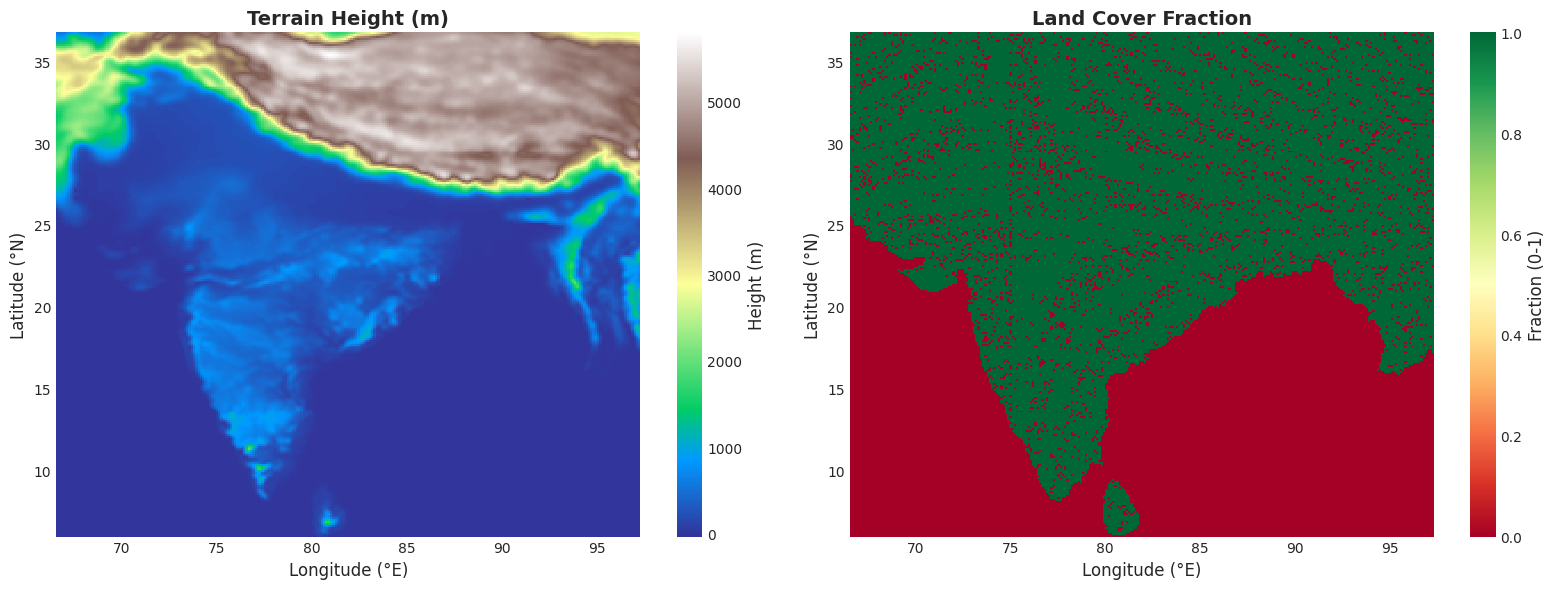


Terrain Statistics:
  Min:  -33.6 m
  Max:  5804.4 m
  Mean: 1113.3 m

Land Cover Statistics:
  Ocean pixels (0.0): 29372 (44.8%)
  Land pixels (1.0):  36164 (55.2%)
  Mixed pixels:       0 (0.0%)


In [19]:
# Load static fields and sample variables for visualization
with h5py.File(sample_file, 'r') as f:
    terrain = f['MTERH'][()]
    land_mask = f['LAND'][()]
    temp = f['TMP'][()]
    precip = f['APCP'][()]
    pressure = f['PRMSL'][()]
    soil_moisture = f['swvl1'][()]
    latent_heat = f['slhf'][()]
    lai_high = f['lai_hv'][()]

# Create meshgrid for plotting
lon_grid, lat_grid = np.meshgrid(lons, lats)

# Plot static fields
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Terrain height
im1 = axes[0].pcolormesh(lon_grid, lat_grid, terrain, cmap='terrain', shading='auto')
axes[0].set_xlabel('Longitude (°E)')
axes[0].set_ylabel('Latitude (°N)')
axes[0].set_title('Terrain Height (m)', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)
cbar1 = plt.colorbar(im1, ax=axes[0])
cbar1.set_label('Height (m)')

# Land mask
im2 = axes[1].pcolormesh(lon_grid, lat_grid, land_mask, cmap='RdYlGn', shading='auto', vmin=0, vmax=1)
axes[1].set_xlabel('Longitude (°E)')
axes[1].set_ylabel('Latitude (°N)')
axes[1].set_title('Land Cover Fraction', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)
cbar2 = plt.colorbar(im2, ax=axes[1])
cbar2.set_label('Fraction (0-1)')

plt.tight_layout()
plt.savefig('/burg-archive/home/mck2199/ML-Project/notebooks/figures/01_data_exploration/01_static_fields.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nTerrain Statistics:")
print(f"  Min:  {np.nanmin(terrain):.1f} m")
print(f"  Max:  {np.nanmax(terrain):.1f} m")
print(f"  Mean: {np.nanmean(terrain):.1f} m")

print(f"\nLand Cover Statistics:")
print(f"  Ocean pixels (0.0): {np.sum(land_mask == 0.0)} ({100*np.sum(land_mask == 0.0)/land_mask.size:.1f}%)")
print(f"  Land pixels (1.0):  {np.sum(land_mask == 1.0)} ({100*np.sum(land_mask == 1.0)/land_mask.size:.1f}%)")
print(f"  Mixed pixels:       {np.sum((land_mask > 0) & (land_mask < 1))} ({100*np.sum((land_mask > 0) & (land_mask < 1))/land_mask.size:.1f}%)")


## 4. Sample IMDAA Variables (Atmospheric)


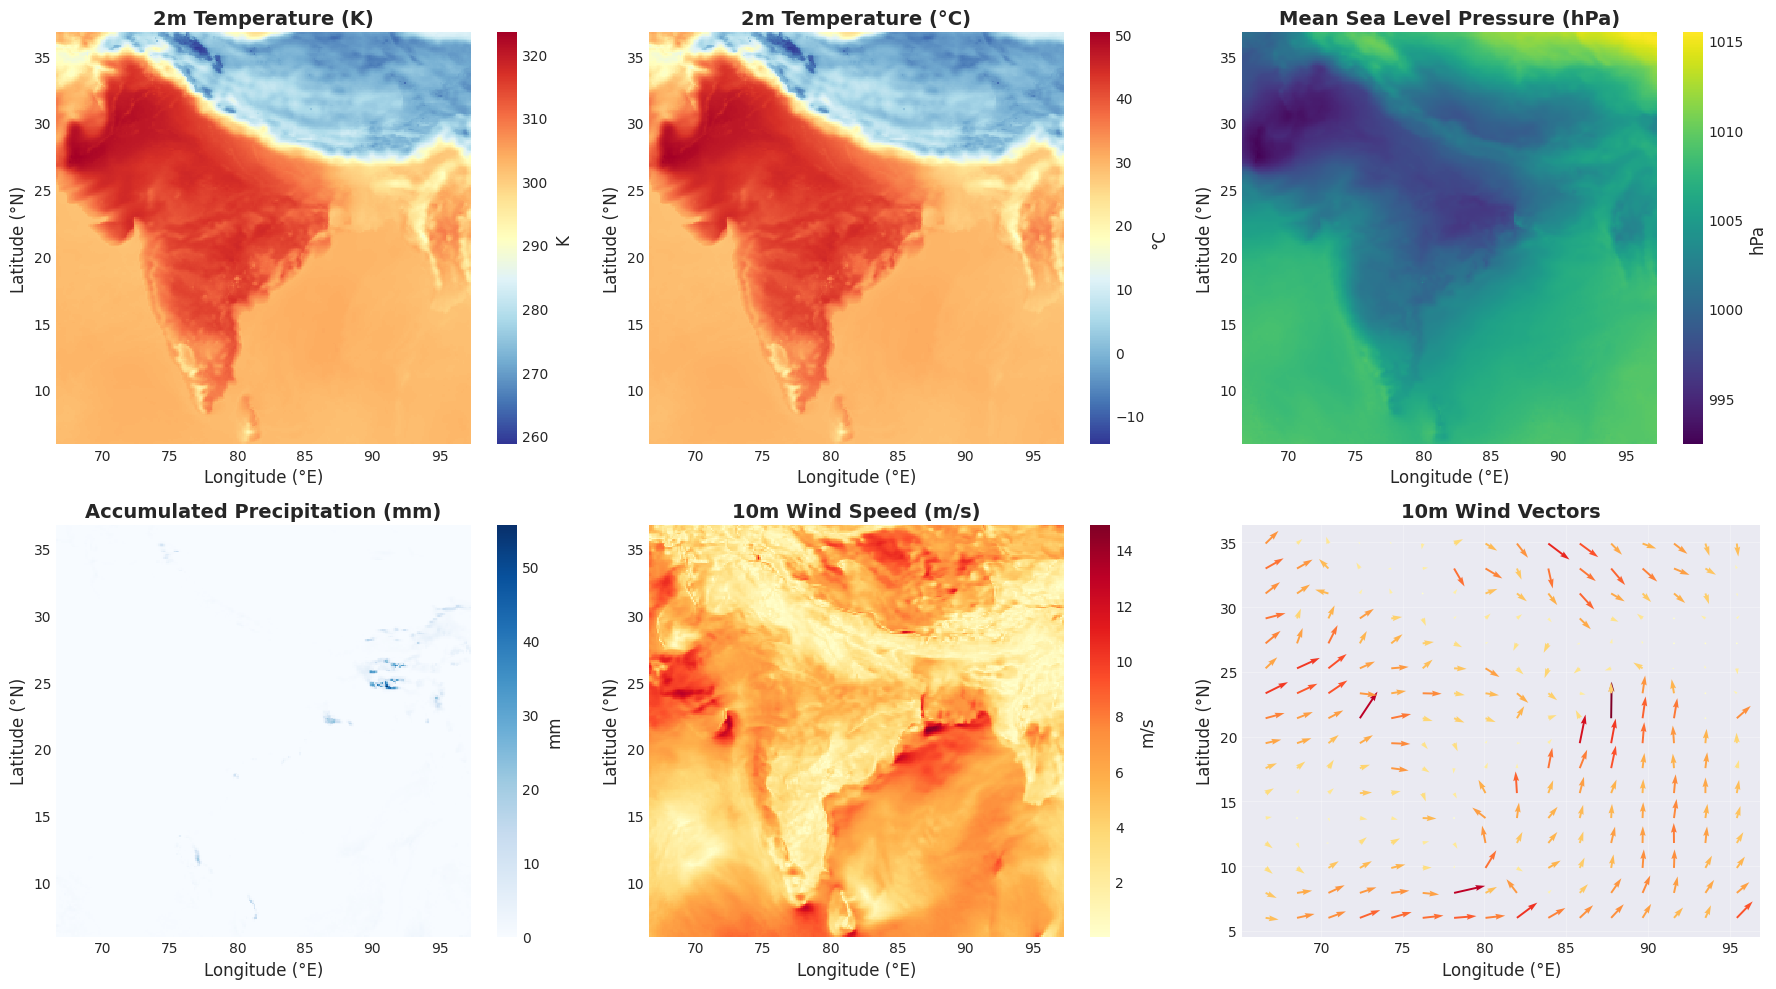

Sample timestamp: 2001-05-07_02.h5

Variable Statistics:
  Temperature:   -14.5°C to 50.3°C (mean: 26.9°C)
  Pressure:      992.4 hPa to 1015.5 hPa (mean: 1004.1 hPa)
  Precipitation: 0.00 mm to 55.61 mm (mean: 0.18 mm)
  Wind Speed:    0.01 m/s to 14.91 m/s (mean: 4.86 m/s)


In [20]:
# Plot IMDAA atmospheric variables
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

# Temperature
im0 = axes[0].pcolormesh(lon_grid, lat_grid, temp, cmap='RdYlBu_r', shading='auto')
axes[0].set_title('2m Temperature (K)', fontweight='bold')
axes[0].set_xlabel('Longitude (°E)')
axes[0].set_ylabel('Latitude (°N)')
plt.colorbar(im0, ax=axes[0], label='K')

# Temperature in Celsius
temp_c = temp - 273.15
im1 = axes[1].pcolormesh(lon_grid, lat_grid, temp_c, cmap='RdYlBu_r', shading='auto')
axes[1].set_title('2m Temperature (°C)', fontweight='bold')
axes[1].set_xlabel('Longitude (°E)')
axes[1].set_ylabel('Latitude (°N)')
plt.colorbar(im1, ax=axes[1], label='°C')

# Mean Sea Level Pressure
pressure_hpa = pressure / 100  # Convert Pa to hPa
im2 = axes[2].pcolormesh(lon_grid, lat_grid, pressure_hpa, cmap='viridis', shading='auto')
axes[2].set_title('Mean Sea Level Pressure (hPa)', fontweight='bold')
axes[2].set_xlabel('Longitude (°E)')
axes[2].set_ylabel('Latitude (°N)')
plt.colorbar(im2, ax=axes[2], label='hPa')

# Precipitation
im3 = axes[3].pcolormesh(lon_grid, lat_grid, precip, cmap='Blues', shading='auto')
axes[3].set_title('Accumulated Precipitation (mm)', fontweight='bold')
axes[3].set_xlabel('Longitude (°E)')
axes[3].set_ylabel('Latitude (°N)')
plt.colorbar(im3, ax=axes[3], label='mm')

# Wind speed
with h5py.File(sample_file, 'r') as f:
    u_wind = f['UGRD'][()]
    v_wind = f['VGRD'][()]
wind_speed = np.sqrt(u_wind**2 + v_wind**2)
im4 = axes[4].pcolormesh(lon_grid, lat_grid, wind_speed, cmap='YlOrRd', shading='auto')
axes[4].set_title('10m Wind Speed (m/s)', fontweight='bold')
axes[4].set_xlabel('Longitude (°E)')
axes[4].set_ylabel('Latitude (°N)')
plt.colorbar(im4, ax=axes[4], label='m/s')

# Wind vectors (downsampled)
skip = 16  # Plot every 16th grid point
axes[5].quiver(lon_grid[::skip, ::skip], lat_grid[::skip, ::skip], 
               u_wind[::skip, ::skip], v_wind[::skip, ::skip],
               wind_speed[::skip, ::skip], cmap='YlOrRd', scale=200)
axes[5].set_title('10m Wind Vectors', fontweight='bold')
axes[5].set_xlabel('Longitude (°E)')
axes[5].set_ylabel('Latitude (°N)')
axes[5].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/burg-archive/home/mck2199/ML-Project/notebooks/figures/01_data_exploration/02_imdaa_atmospheric.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Sample timestamp: {os.path.basename(sample_file)}")
print(f"\nVariable Statistics:")
print(f"  Temperature:   {np.nanmin(temp_c):.1f}°C to {np.nanmax(temp_c):.1f}°C (mean: {np.nanmean(temp_c):.1f}°C)")
print(f"  Pressure:      {np.nanmin(pressure_hpa):.1f} hPa to {np.nanmax(pressure_hpa):.1f} hPa (mean: {np.nanmean(pressure_hpa):.1f} hPa)")
print(f"  Precipitation: {np.nanmin(precip):.2f} mm to {np.nanmax(precip):.2f} mm (mean: {np.nanmean(precip):.2f} mm)")
print(f"  Wind Speed:    {np.nanmin(wind_speed):.2f} m/s to {np.nanmax(wind_speed):.2f} m/s (mean: {np.nanmean(wind_speed):.2f} m/s)")


## 5. ERA5-Land Variables Visualization


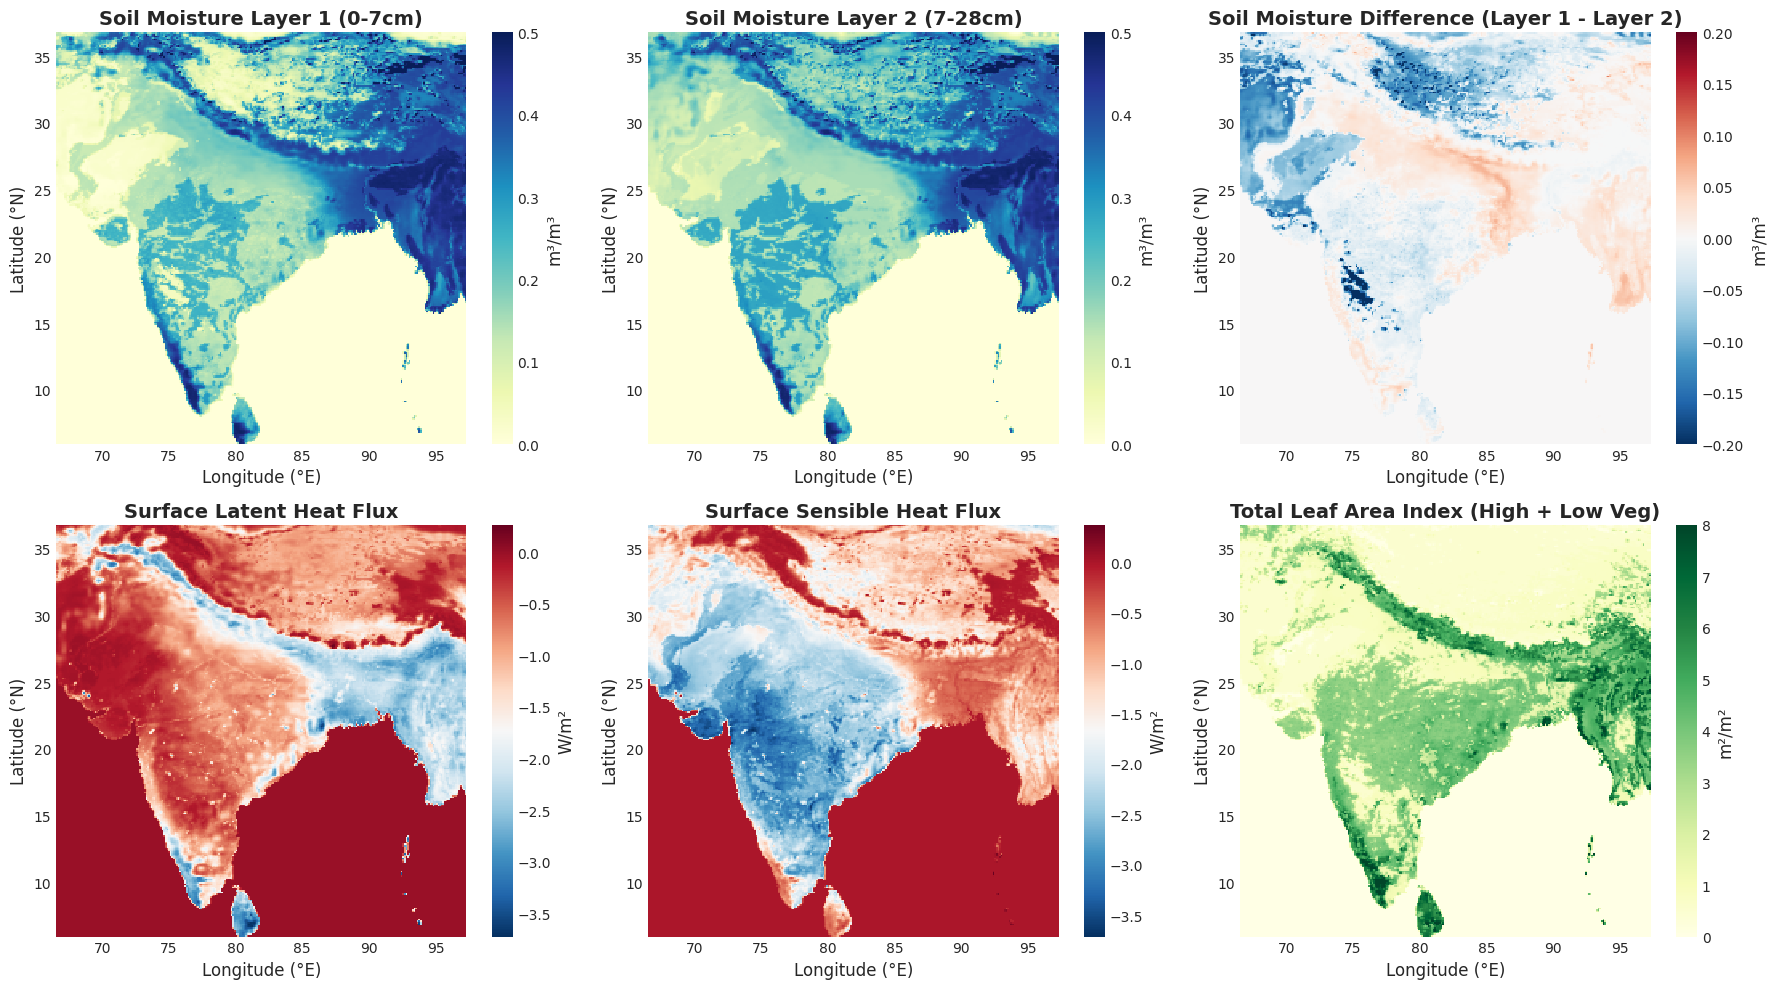

ERA5-Land Variable Statistics:
  Soil Moisture L1:    0.000 to 0.698 m³/m³ (mean: 0.145)
  Soil Moisture L2:    0.000 to 0.684 m³/m³ (mean: 0.157)
  Latent Heat Flux:    -3.7 to 0.3 W/m² (mean: -0.7)
  Sensible Heat Flux:  -3.7 to 0.4 W/m² (mean: -1.0)
  LAI High Veg:        0.00 to 6.08 m²/m² (mean: 0.75)
  LAI Low Veg:         0.00 to 4.11 m²/m² (mean: 0.73)


In [21]:
# Plot ERA5-Land variables
with h5py.File(sample_file, 'r') as f:
    swvl1 = f['swvl1'][()]
    swvl2 = f['swvl2'][()]
    slhf = f['slhf'][()]
    sshf = f['sshf'][()]
    lai_hv = f['lai_hv'][()]
    lai_lv = f['lai_lv'][()]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

# Soil Moisture Layer 1
im0 = axes[0].pcolormesh(lon_grid, lat_grid, swvl1, cmap='YlGnBu', shading='auto', vmin=0, vmax=0.5)
axes[0].set_title('Soil Moisture Layer 1 (0-7cm)', fontweight='bold')
axes[0].set_xlabel('Longitude (°E)')
axes[0].set_ylabel('Latitude (°N)')
cbar0 = plt.colorbar(im0, ax=axes[0])
cbar0.set_label('m³/m³')

# Soil Moisture Layer 2
im1 = axes[1].pcolormesh(lon_grid, lat_grid, swvl2, cmap='YlGnBu', shading='auto', vmin=0, vmax=0.5)
axes[1].set_title('Soil Moisture Layer 2 (7-28cm)', fontweight='bold')
axes[1].set_xlabel('Longitude (°E)')
axes[1].set_ylabel('Latitude (°N)')
cbar1 = plt.colorbar(im1, ax=axes[1])
cbar1.set_label('m³/m³')

# Difference between layers
im2 = axes[2].pcolormesh(lon_grid, lat_grid, swvl1 - swvl2, cmap='RdBu_r', shading='auto', vmin=-0.2, vmax=0.2)
axes[2].set_title('Soil Moisture Difference (Layer 1 - Layer 2)', fontweight='bold')
axes[2].set_xlabel('Longitude (°E)')
axes[2].set_ylabel('Latitude (°N)')
cbar2 = plt.colorbar(im2, ax=axes[2])
cbar2.set_label('m³/m³')

# Surface Latent Heat Flux
im3 = axes[3].pcolormesh(lon_grid, lat_grid, slhf, cmap='RdBu_r', shading='auto')
axes[3].set_title('Surface Latent Heat Flux', fontweight='bold')
axes[3].set_xlabel('Longitude (°E)')
axes[3].set_ylabel('Latitude (°N)')
cbar3 = plt.colorbar(im3, ax=axes[3])
cbar3.set_label('W/m²')

# Surface Sensible Heat Flux
im4 = axes[4].pcolormesh(lon_grid, lat_grid, sshf, cmap='RdBu_r', shading='auto')
axes[4].set_title('Surface Sensible Heat Flux', fontweight='bold')
axes[4].set_xlabel('Longitude (°E)')
axes[4].set_ylabel('Latitude (°N)')
cbar4 = plt.colorbar(im4, ax=axes[4])
cbar4.set_label('W/m²')

# Total LAI (high + low vegetation)
lai_total = lai_hv + lai_lv
im5 = axes[5].pcolormesh(lon_grid, lat_grid, lai_total, cmap='YlGn', shading='auto', vmin=0, vmax=8)
axes[5].set_title('Total Leaf Area Index (High + Low Veg)', fontweight='bold')
axes[5].set_xlabel('Longitude (°E)')
axes[5].set_ylabel('Latitude (°N)')
cbar5 = plt.colorbar(im5, ax=axes[5])
cbar5.set_label('m²/m²')

plt.tight_layout()
plt.savefig('/burg-archive/home/mck2199/ML-Project/notebooks/figures/01_data_exploration/03_era5land_variables.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"ERA5-Land Variable Statistics:")
print(f"  Soil Moisture L1:    {np.nanmin(swvl1):.3f} to {np.nanmax(swvl1):.3f} m³/m³ (mean: {np.nanmean(swvl1):.3f})")
print(f"  Soil Moisture L2:    {np.nanmin(swvl2):.3f} to {np.nanmax(swvl2):.3f} m³/m³ (mean: {np.nanmean(swvl2):.3f})")
print(f"  Latent Heat Flux:    {np.nanmin(slhf):.1f} to {np.nanmax(slhf):.1f} W/m² (mean: {np.nanmean(slhf):.1f})")
print(f"  Sensible Heat Flux:  {np.nanmin(sshf):.1f} to {np.nanmax(sshf):.1f} W/m² (mean: {np.nanmean(sshf):.1f})")
print(f"  LAI High Veg:        {np.nanmin(lai_hv):.2f} to {np.nanmax(lai_hv):.2f} m²/m² (mean: {np.nanmean(lai_hv):.2f})")
print(f"  LAI Low Veg:         {np.nanmin(lai_lv):.2f} to {np.nanmax(lai_lv):.2f} m²/m² (mean: {np.nanmean(lai_lv):.2f})")


## 6. Temporal Coverage and Distribution


In [22]:
# Parse timestamps from filenames
def parse_filename(filename):
    basename = os.path.basename(filename)
    # Format: YYYY-MM-DD_HH.h5
    date_str = basename.replace('.h5', '')
    return pd.to_datetime(date_str, format='%Y-%m-%d_%H')

# Create dataframes for each split
train_df = pd.DataFrame({'filename': train_files})
train_df['timestamp'] = train_df['filename'].apply(parse_filename)
train_df['split'] = 'train'

val_df = pd.DataFrame({'filename': val_files})
val_df['timestamp'] = val_df['filename'].apply(parse_filename)
val_df['split'] = 'val'

test_df = pd.DataFrame({'filename': test_files})
test_df['timestamp'] = test_df['filename'].apply(parse_filename)
test_df['split'] = 'test'

# Combine
all_df = pd.concat([train_df, val_df, test_df], ignore_index=True)
all_df = all_df.sort_values('timestamp').reset_index(drop=True)

print("Temporal Coverage:")
print(f"  Overall:    {all_df['timestamp'].min()} to {all_df['timestamp'].max()}")
print(f"  Training:   {train_df['timestamp'].min()} to {train_df['timestamp'].max()} ({len(train_df)} samples)")
print(f"  Validation: {val_df['timestamp'].min()} to {val_df['timestamp'].max()} ({len(val_df)} samples)")
print(f"  Test:       {test_df['timestamp'].min()} to {test_df['timestamp'].max()} ({len(test_df)} samples)")
print(f"\nTotal Duration: {(all_df['timestamp'].max() - all_df['timestamp'].min()).days} days")
print(f"Total Samples:  {len(all_df)}")


Temporal Coverage:
  Overall:    2000-01-01 00:00:00 to 2019-12-31 03:00:00
  Training:   2000-01-01 00:00:00 to 2017-12-31 02:00:00 (20031 samples)
  Validation: 2018-01-01 00:00:00 to 2018-12-31 03:00:00 (1460 samples)
  Test:       2019-01-01 00:00:00 to 2019-12-31 03:00:00 (1460 samples)

Total Duration: 7304 days
Total Samples:  22951


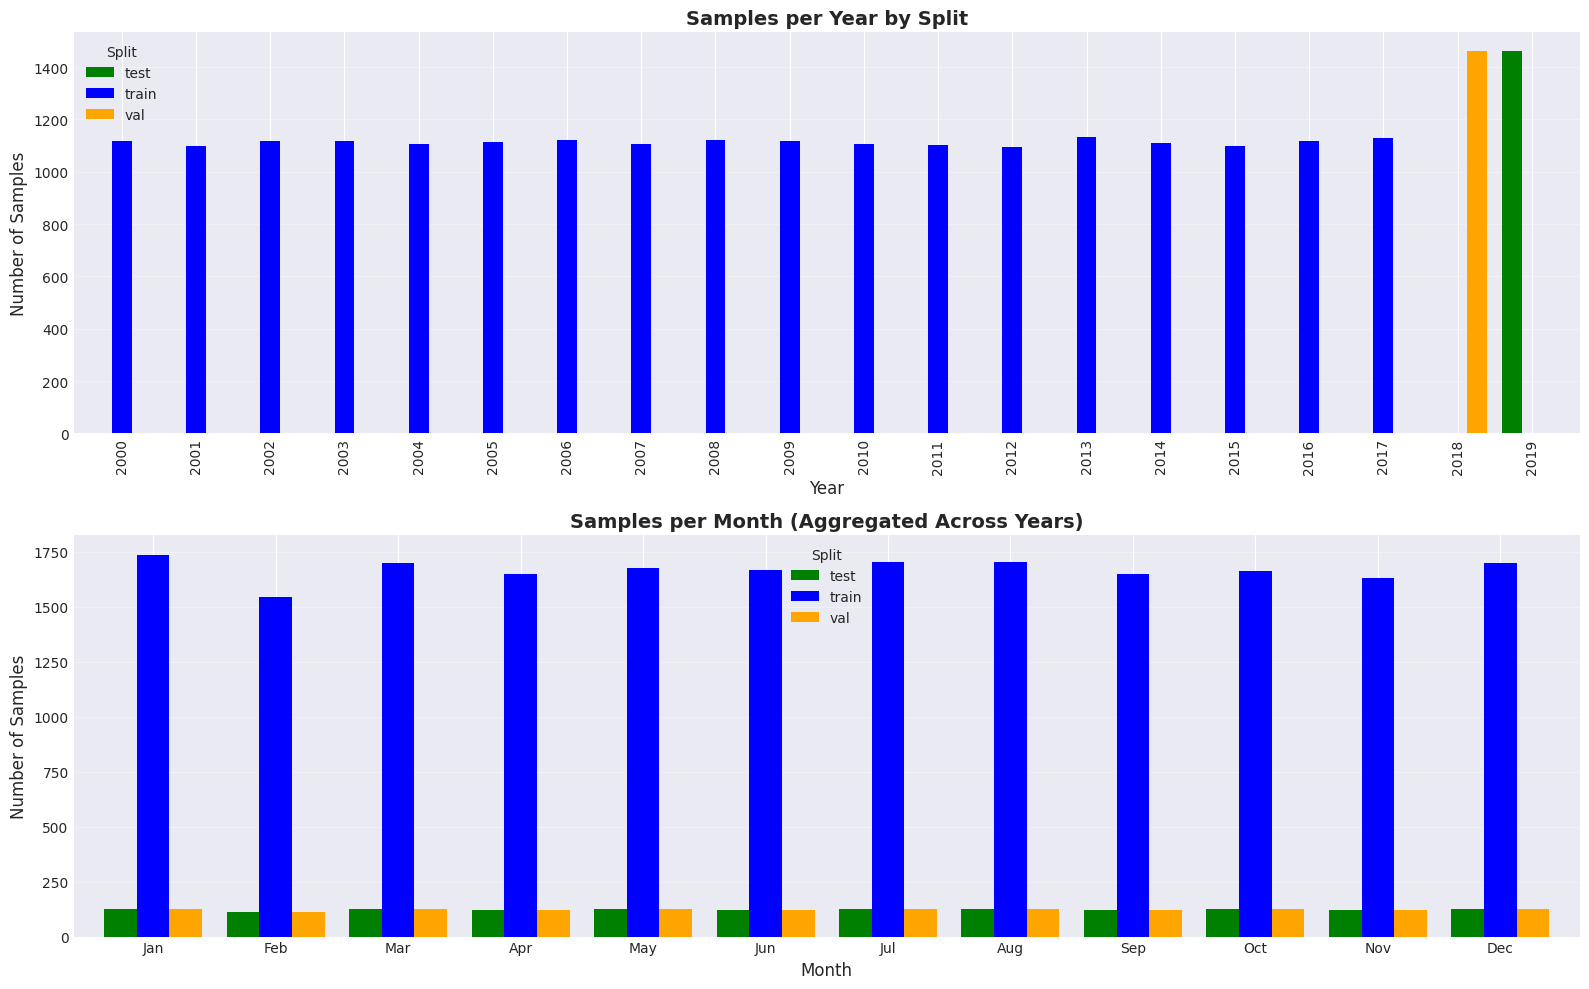

In [23]:
# Visualize temporal distribution
fig, axes = plt.subplots(2, 1, figsize=(16, 10))

# Samples per year
all_df['year'] = all_df['timestamp'].dt.year
yearly_counts = all_df.groupby(['year', 'split']).size().unstack(fill_value=0)
colors = {'train': 'blue', 'val': 'orange', 'test': 'green'}
yearly_counts.plot(kind='bar', ax=axes[0], color=[colors[s] for s in yearly_counts.columns], width=0.8)
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Number of Samples')
axes[0].set_title('Samples per Year by Split', fontsize=14, fontweight='bold')
axes[0].legend(title='Split')
axes[0].grid(True, alpha=0.3, axis='y')

# Samples per month (aggregated across years)
all_df['month'] = all_df['timestamp'].dt.month
monthly_counts = all_df.groupby(['month', 'split']).size().unstack(fill_value=0)
monthly_counts.plot(kind='bar', ax=axes[1], color=[colors[s] for s in monthly_counts.columns], width=0.8)
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Number of Samples')
axes[1].set_title('Samples per Month (Aggregated Across Years)', fontsize=14, fontweight='bold')
axes[1].set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'], rotation=0)
axes[1].legend(title='Split')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('/burg-archive/home/mck2199/ML-Project/notebooks/figures/01_data_exploration/04_temporal_distribution.png', dpi=150, bbox_inches='tight')
plt.show()


## 7. Seasonal Patterns

Let's examine seasonal variations in key variables, particularly important for understanding the Indian monsoon.


In [24]:
# Sample files across different seasons from 2010
year_2010_files = [f for f in train_files if '2010' in os.path.basename(f)]

# Select representative dates for each season
seasonal_files = {
    'Winter (Jan)': [f for f in year_2010_files if '2010-01-15' in os.path.basename(f)][0],
    'Pre-monsoon (Apr)': [f for f in year_2010_files if '2010-04-15' in os.path.basename(f)][0],
    'Monsoon (Jul)': [f for f in year_2010_files if '2010-08-15' in os.path.basename(f)][0],
    'Post-monsoon (Oct)': [f for f in year_2010_files if '2010-10-15' in os.path.basename(f)][0],
}

# Load temperature and soil moisture for each season
seasonal_data = {}
for season, filepath in seasonal_files.items():
    with h5py.File(filepath, 'r') as f:
        seasonal_data[season] = {
            'temp': f['TMP'][()] - 273.15,  # Convert to Celsius
            'precip': f['APCP'][()],
            'swvl1': f['swvl1'][()],
            'lai_total': f['lai_hv'][()] + f['lai_lv'][()],
        }

print("Seasonal samples loaded for 2010:")
for season in seasonal_data.keys():
    print(f"  - {season}")


Seasonal samples loaded for 2010:
  - Winter (Jan)
  - Pre-monsoon (Apr)
  - Monsoon (Jul)
  - Post-monsoon (Oct)


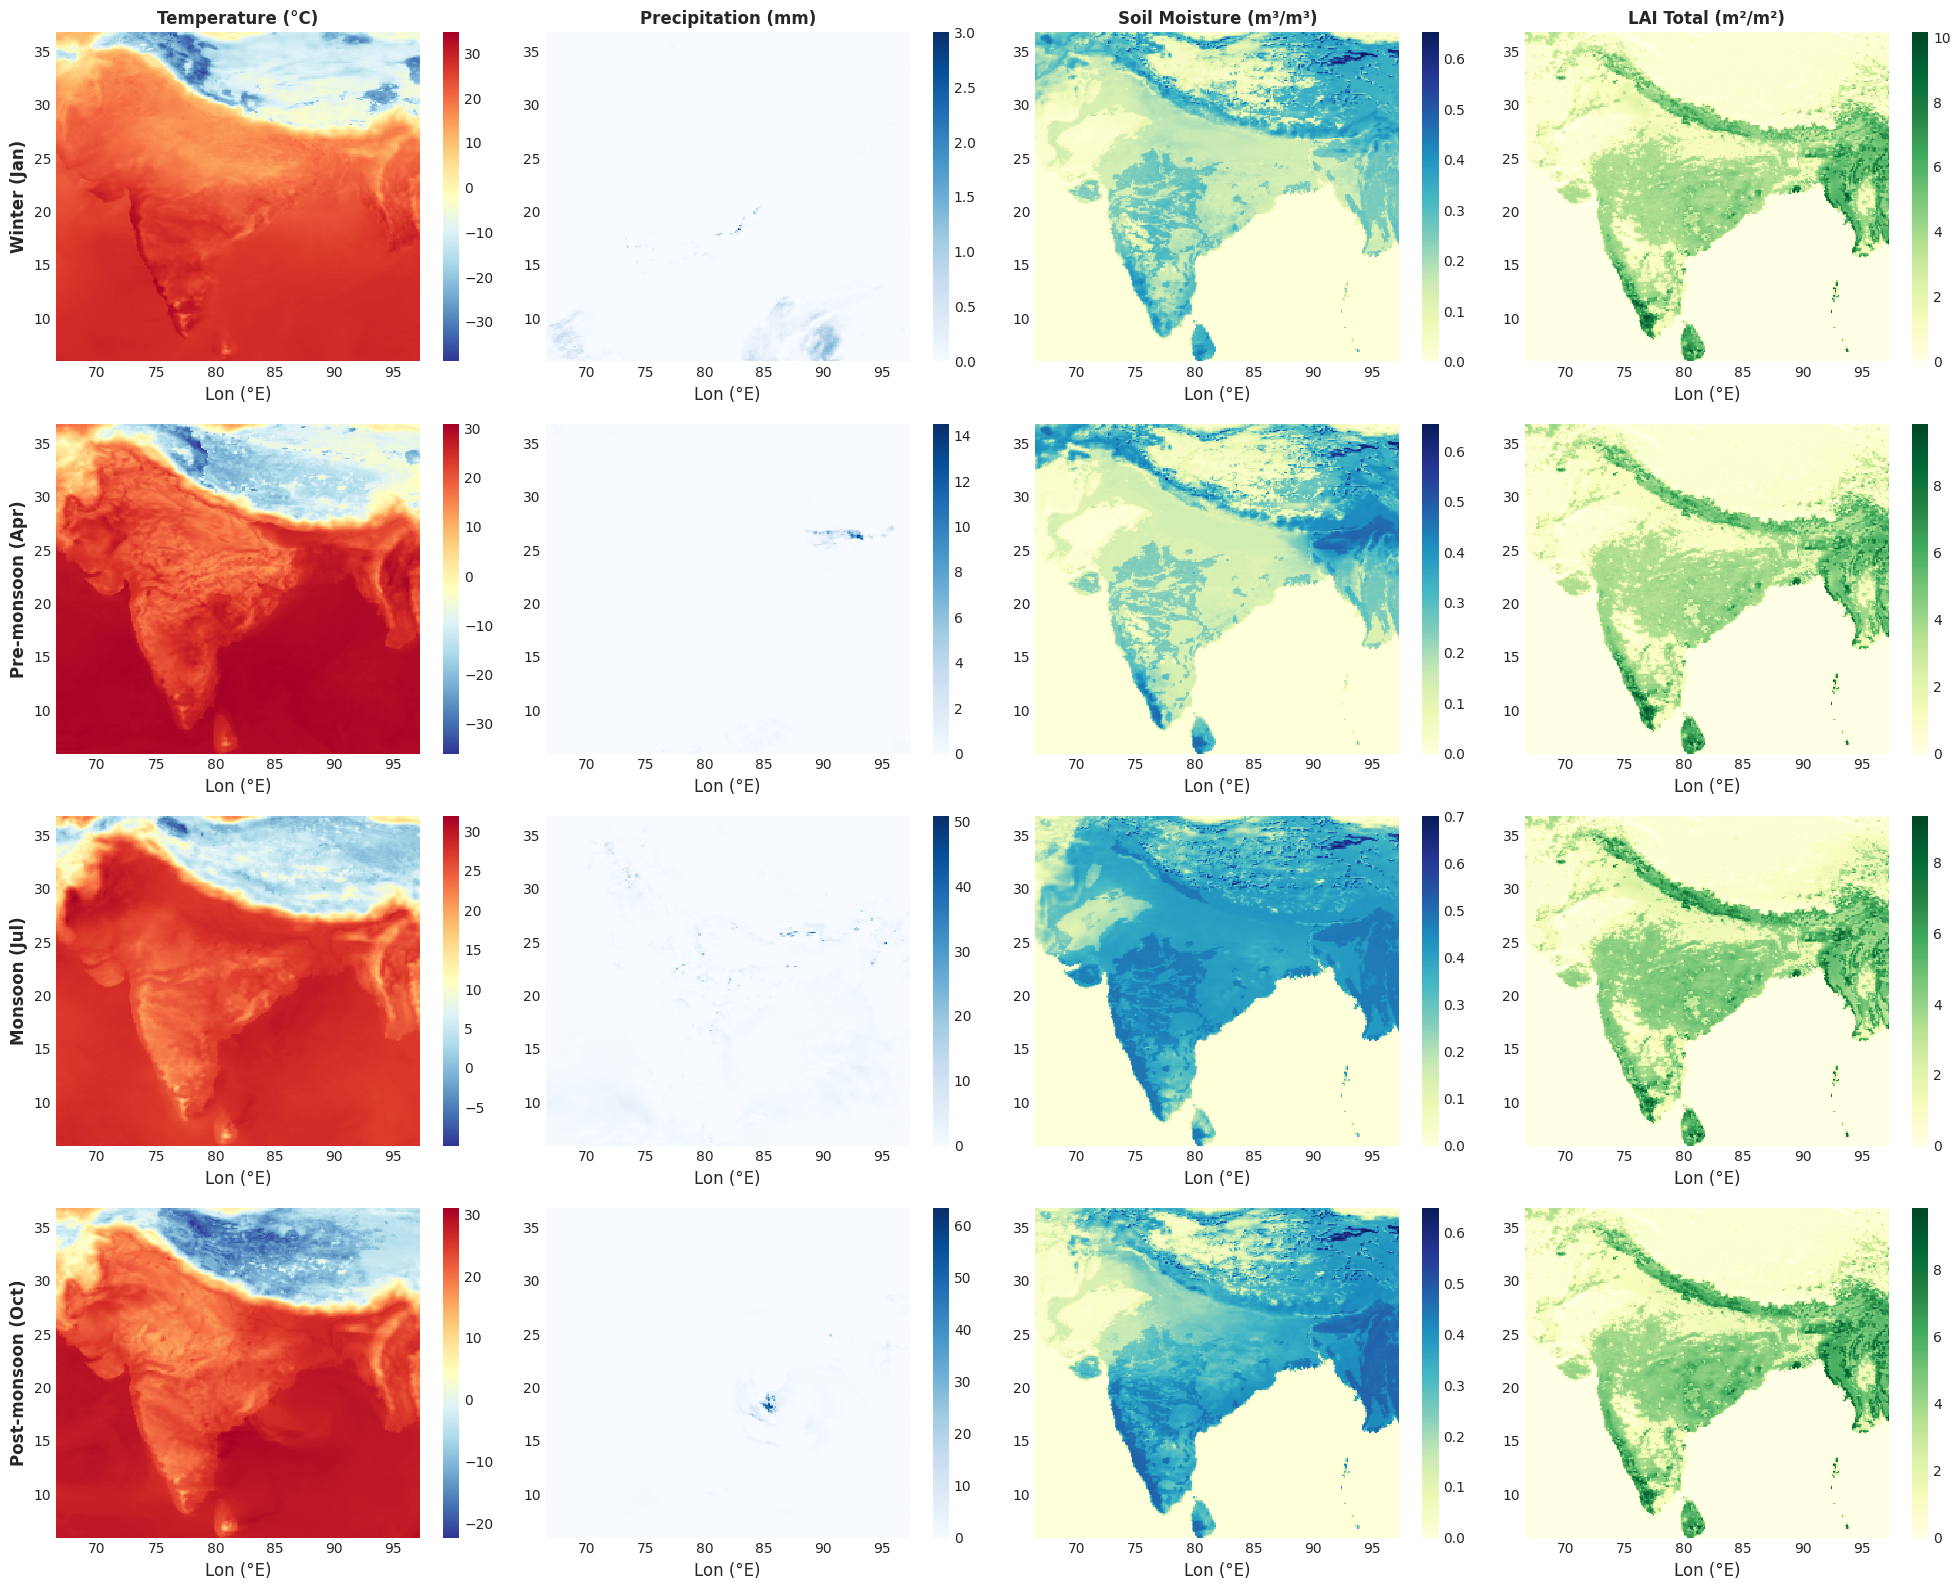


Seasonal Statistics (2010):

Winter (Jan):
  Temperature (°C)              : mean=  16.58, std=  15.27, min= -38.83, max=  34.73
  Precipitation (mm)            : mean=   0.02, std=   0.09, min=   0.00, max=   3.00
  Soil Moisture (m³/m³)         : mean=   0.13, std=   0.13, min=   0.00, max=   0.65
  LAI Total (m²/m²)             : mean=   1.53, std=   1.96, min=   0.00, max=  10.15

Pre-monsoon (Apr):
  Temperature (°C)              : mean=  18.03, std=  15.30, min= -36.07, max=  30.84
  Precipitation (mm)            : mean=   0.02, std=   0.28, min=   0.00, max=  14.50
  Soil Moisture (m³/m³)         : mean=   0.12, std=   0.14, min=   0.00, max=   0.65
  LAI Total (m²/m²)             : mean=   1.47, std=   1.88, min=   0.00, max=   9.82

Monsoon (Jul):
  Temperature (°C)              : mean=  22.23, std=   9.01, min=  -9.83, max=  31.89
  Precipitation (mm)            : mean=   0.47, std=   1.05, min=   0.00, max=  50.81
  Soil Moisture (m³/m³)         : mean=   0.23, std=   0.20,

In [25]:
# Plot seasonal variations
fig, axes = plt.subplots(4, 4, figsize=(20, 16))

variables = ['temp', 'precip', 'swvl1', 'lai_total']
var_names = ['Temperature (°C)', 'Precipitation (mm)', 'Soil Moisture (m³/m³)', 'LAI Total (m²/m²)']
cmaps = ['RdYlBu_r', 'Blues', 'YlGnBu', 'YlGn']

for i, season in enumerate(seasonal_data.keys()):
    for j, (var, var_name, cmap) in enumerate(zip(variables, var_names, cmaps)):
        im = axes[i, j].pcolormesh(lon_grid, lat_grid, seasonal_data[season][var], 
                                    cmap=cmap, shading='auto')
        if j == 0:
            axes[i, j].set_ylabel(season, fontsize=12, fontweight='bold')
        if i == 0:
            axes[i, j].set_title(var_name, fontsize=12, fontweight='bold')
        axes[i, j].set_xlabel('Lon (°E)')
        plt.colorbar(im, ax=axes[i, j])

plt.tight_layout()
plt.savefig('/burg-archive/home/mck2199/ML-Project/notebooks/figures/01_data_exploration/05_seasonal_patterns.png', dpi=150, bbox_inches='tight')
plt.show()

# Print seasonal statistics
print("\nSeasonal Statistics (2010):")
print("="*80)
for season in seasonal_data.keys():
    print(f"\n{season}:")
    for var, var_name in zip(variables, var_names):
        data = seasonal_data[season][var]
        print(f"  {var_name:30s}: mean={np.nanmean(data):7.2f}, std={np.nanstd(data):7.2f}, "
              f"min={np.nanmin(data):7.2f}, max={np.nanmax(data):7.2f}")


## 8. Summary and Key Insights


In [26]:
print("="*80)
print("INDIAWEATHERBENCH DATA EXPLORATION SUMMARY")
print("="*80)

print("\n1. DATASET OVERVIEW")
print("-"*80)
print(f"   Source: IMDAA (atmospheric) + ERA5-Land (land surface)")
print(f"   Period: {all_df['timestamp'].min().date()} to {all_df['timestamp'].max().date()}")
print(f"   Total samples: {len(all_df)} (6-hourly)")
print(f"   Spatial domain: {lat_min}°N-{lat_max}°N, {lon_min}°E-{lon_max}°E")
print(f"   Grid size: {grid_size}×{grid_size} (~12 km resolution)")

print("\n2. VARIABLES")
print("-"*80)
print(f"   IMDAA Surface: {len(imdaa_surface)} variables")
print(f"   IMDAA Pressure Levels: {len(imdaa_pressure)} variables (7 levels × 5 fields)")
print(f"   ERA5-Land: {len(era5land_vars)} variables")
print(f"   Static fields: {len(static_vars)} variables")
print(f"   Total dynamic variables: {len(imdaa_surface) + len(imdaa_pressure) + len(era5land_vars)}")

print("\n3. DATA SPLITS")
print("-"*80)
print(f"   Training:   {len(train_files)} samples (2000-2017)")
print(f"   Validation: {len(val_files)} samples (2018)")
print(f"   Test:       {len(test_files)} samples (2019)")

print("\n4. KEY ERA5-LAND INTEGRATION")
print("-"*80)
print("   Added variables:")
for var in era5land_vars:
    print(f"     • {var}: {var_descriptions.get(var, 'N/A')}")

print("\n5. SEASONAL CHARACTERISTICS")
print("-"*80)
print("   • Strong monsoon signal in precipitation (Jul-Sep)")
print("   • Temperature range: ~5-45°C across domain")
print("   • Soil moisture shows clear seasonal cycle")
print("   • LAI peaks during monsoon season")

print("\n6. TERRAIN CHARACTERISTICS")
print("-"*80)
print(f"   • Elevation range: {np.nanmin(terrain):.0f}m to {np.nanmax(terrain):.0f}m")
print(f"   • Himalayas visible in northern domain")
print(f"   • Western Ghats visible along west coast")
print(f"   • Land fraction: {100*np.sum(land_mask > 0.5)/land_mask.size:.1f}%")

print("\n7. FILES GENERATED")
print("-"*80)
figures_dir = Path('/burg-archive/home/mck2199/ML-Project/notebooks/figures')
if figures_dir.exists():
    for fig_file in sorted(figures_dir.glob('*.png')):
        print(f"   • {fig_file.name}")

print("\n" + "="*80)
print("Data exploration complete!")
print("="*80)


INDIAWEATHERBENCH DATA EXPLORATION SUMMARY

1. DATASET OVERVIEW
--------------------------------------------------------------------------------
   Source: IMDAA (atmospheric) + ERA5-Land (land surface)
   Period: 2000-01-01 to 2019-12-31
   Total samples: 22951 (6-hourly)
   Spatial domain: 6.0°N-36.72°N, 66.6°E-97.25°E
   Grid size: 256×256 (~12 km resolution)

2. VARIABLES
--------------------------------------------------------------------------------
   IMDAA Surface: 6 variables
   IMDAA Pressure Levels: 35 variables (7 levels × 5 fields)
   ERA5-Land: 6 variables
   Static fields: 2 variables
   Total dynamic variables: 47

3. DATA SPLITS
--------------------------------------------------------------------------------
   Training:   20031 samples (2000-2017)
   Validation: 1460 samples (2018)
   Test:       1460 samples (2019)

4. KEY ERA5-LAND INTEGRATION
--------------------------------------------------------------------------------
   Added variables:
     • swvl1: Soil Mois

## References

1. **IndiaWeatherBench Paper**: [arXiv:2509.00653](https://arxiv.org/abs/2509.00653)
2. **IMDAA Dataset**: Indian Monsoon Data Assimilation and Analysis (NCMRWF)
3. **ERA5-Land**: [Copernicus Climate Data Store](https://cds.climate.copernicus.eu/datasets/reanalysis-era5-land)
4. **Project Repository**: `/burg-archive/home/mck2199/ML-Project/IndiaWeatherBench/`
5. **Integration Documentation**: `ERA5LAND_INTEGRATION.md`

---

**Next Steps:**
- Explore model architectures in `/burg-archive/home/mck2199/ML-Project/IndiaWeatherBench/india_benchmark/models/`
- Review training configurations in `/burg-archive/home/mck2199/ML-Project/configs/`
- Check training results in `/burg-archive/home/mck2199/ML-Project/checkpoints_era5land/`
